# Cat Boost:

### Importando as bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from catboost import CatBoostClassifier
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 2. Carregamento dos Artefatos e dos Dados

 Seguindo nossa metodologia, o primeiro passo é carregar os artefatos do Notebook 01.
 Isso garante que o CatBoost seja treinado e avaliado sob as mesmas condições dos modelos anteriores.

 **NOTA IMPORTANTE:** Assim como o Random Forest e o XGBoost, o CatBoost é um modelo baseado em árvores. Portanto, a **padronização de features (`StandardScaler`) não é necessária**. Vamos carregar os dados brutos e usá-los diretamente.

In [2]:
# --- 1. Carrega os artefatos salvos ---

try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

# Carrega o codificador de rótulos e a lista de features
try:
    label_encoder = joblib.load(os.path.join(model_dir, 'label_encoder.joblib'))
    features_realistas = joblib.load(os.path.join(model_dir, 'features_realistas.joblib'))
    print("Artefatos (LabelEncoder e lista de features) carregados com sucesso.")
    print(f"Número de features a serem usadas: {len(features_realistas)}")
except FileNotFoundError:
    raise RuntimeError("ERRO: Artefatos do Notebook 01 não encontrados. Por favor, execute o notebook 01-RandomForest primeiro.")

# --- 2. Carrega e limpa os dados ---

caminho_dados = os.path.join(project_root, 'MachineLearningCSV', 'MachineLearningCVE')
todos_os_arquivos = glob.glob(os.path.join(caminho_dados, "*.csv"))

lista_de_dfs = []
for arquivo in todos_os_arquivos:
    df = pd.read_csv(arquivo, low_memory=False)
    lista_de_dfs.append(df)

dados = pd.concat(lista_de_dfs, axis=0, ignore_index=True)

# Limpeza
dados.columns = dados.columns.str.strip()
for col in dados.columns:
    if dados[col].dtype == 'object' and col != 'Label':
        dados[col] = pd.to_numeric(dados[col], errors='coerce')
dados.replace([np.inf, -np.inf], np.nan, inplace=True)
dados.dropna(inplace=True)

# Separação e codificação
X_bruto = dados.drop('Label', axis=1)
y_bruto = dados['Label']

# Usa o LabelEncoder JÁ CARREGADO para transformar os rótulos
y_codificado = label_encoder.transform(y_bruto)

# Seleciona apenas as features realistas do DataFrame recém-carregado
X_realista = X_bruto[features_realistas]

print("\nDataset carregado e processado com sucesso.")
print(f"Shape do DataFrame de features (X_realista): {X_realista.shape}")

Artefatos (LabelEncoder e lista de features) carregados com sucesso.
Número de features a serem usadas: 14

Dataset carregado e processado com sucesso.
Shape do DataFrame de features (X_realista): (2827876, 14)


### 3. Divisão dos Dados em Treino e Teste

 Repetimos esta etapa de forma idêntica aos notebooks anteriores.
 A utilização do mesmo `random_state=42` é o que garante que os modelos sejam expostos exatamente aos mesmos dados de treino e avaliados exatamente nos mesmos dados de teste, tornando a comparação de performance o mais justa e rigorosa possível.

In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_realista,
    y_codificado,
    test_size=0.3,
    random_state=42,  # Essencial manter o mesmo random_state
    stratify=y_codificado
)

print("Divisão dos dados concluída.")
print(f"Shape do conjunto de treino (X_treino): {X_treino.shape}")
print(f"Shape do conjunto de teste (X_teste):   {X_teste.shape}")


Divisão dos dados concluída.
Shape do conjunto de treino (X_treino): (1979513, 14)
Shape do conjunto de teste (X_teste):   (848363, 14)


### 4. Otimização com GridSearchCV e Validação Cruzada

Para validar e refinar o modelo CatBoost, aplicamos o `GridSearchCV` no conjunto de treino completo. O objetivo é explorar sistematicamente os hiperparâmetros mais influentes, como o número de iterações, a profundidade das árvores e a taxa de aprendizado. Este processo, embora computacionalmente intensivo, é essencial para garantir que o modelo final não apenas tenha uma alta performance, mas também seja robusto e bem generalizado, conforme validado pela metodologia de validação cruzada.

In [4]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

print("--- Iniciando GridSearchCV para o CatBoostClassifier ---")
print("AVISO: Este processo será demorado e usará o conjunto de treino COMPLETO.")

# 1. Define a grade de parâmetros para o CatBoost
# O CatBoost tem muitos parâmetros, focamos nos mais importantes.
param_grid_cat = {
    'iterations': [500, 1000],  # Equivalente ao n_estimators
    'depth': [4, 6],           # Profundidade das árvores
    'learning_rate': [0.05, 0.1] # Taxa de aprendizado
}

# 2. Instancia o GridSearchCV
# verbose=0 dentro do CatBoostClassifier é importante para não poluir a saída do GridSearchCV.
grid_search_cat = GridSearchCV(
    estimator=CatBoostClassifier(random_state=42, verbose=0),
    param_grid=param_grid_cat,
    cv=3,
    n_jobs=2,
    verbose=2, # verbose do GridSearchCV para vermos o progresso
    scoring='f1_weighted'
)

# 3. Executa a busca no CONJUNTO DE TREINO COMPLETO
# Este passo levará várias horas.
grid_search_cat.fit(X_treino, y_treino)

# 4. Mostra os melhores parâmetros encontrados
print("\n--- GridSearchCV Concluído ---")
print("Melhores parâmetros encontrados para CatBoost:")
print(grid_search_cat.best_params_)

# Armazena os melhores parâmetros para usar na próxima etapa
best_cat_params = grid_search_cat.best_params_

--- Iniciando GridSearchCV para o CatBoostClassifier ---
AVISO: Este processo será demorado e usará o conjunto de treino COMPLETO.
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ........depth=4, iterations=500, learning_rate=0.05; total time= 6.6min
[CV] END ........depth=4, iterations=500, learning_rate=0.05; total time= 6.6min
[CV] END .........depth=4, iterations=500, learning_rate=0.1; total time= 6.6min
[CV] END ........depth=4, iterations=500, learning_rate=0.05; total time= 6.6min
[CV] END .........depth=4, iterations=500, learning_rate=0.1; total time= 6.6min
[CV] END .........depth=4, iterations=500, learning_rate=0.1; total time= 6.6min
[CV] END .......depth=4, iterations=1000, learning_rate=0.05; total time=13.0min
[CV] END .......depth=4, iterations=1000, learning_rate=0.05; total time=13.1min
[CV] END ........depth=4, iterations=1000, learning_rate=0.1; total time=12.9min
[CV] END .......depth=4, iterations=1000, learning_rate=0.05; total time=13.0min

### 4. Treinamento do Modelo CatBoost

 O CatBoost (Categorical Boosting) é o nosso terceiro modelo.

#### Principais Vantagens:
 - **Robustez:** Geralmente é menos sensível a hiperparâmetros do que XGBoost e LightGBM.
 - **Mecanismos Internos:** Possui estratégias internas para combater o overfitting e lidar com o desbalanceamento de classes.

 Vamos usar o parâmetro `auto_class_weights='Balanced'` para que o próprio CatBoost tente compensar o desbalanceamento dos nossos dados. Isso pode dar a ele uma vantagem e evitar o fracasso que vimos no LightGBM.
 O parâmetro `verbose=50` fará com que o modelo imprima o progresso do treinamento a cada 50 árvores.

In [5]:
print("--- Treinando o Modelo CatBoost Final com os Parâmetros Otimizados ---")

# Instancia o modelo com os MELHORES parâmetros encontrados pelo GridSearchCV
cat_model = CatBoostClassifier(
    random_state=42,
    verbose=100, # Mostra o progresso a cada 100 iterações
    **best_cat_params  # <-- Desempacota o dicionário de parâmetros otimizados
)

# Treina o modelo final no conjunto de treino COMPLETO
cat_model.fit(X_treino, y_treino)

print("\n--- Treinamento do modelo final concluído ---")

--- Treinando o Modelo CatBoost Final com os Parâmetros Otimizados ---
0:	learn: 1.5736263	total: 994ms	remaining: 16m 32s
100:	learn: 0.0624133	total: 1m 31s	remaining: 13m 31s
200:	learn: 0.0552784	total: 3m 2s	remaining: 12m 4s
300:	learn: 0.0535789	total: 4m 33s	remaining: 10m 34s
400:	learn: 0.0529018	total: 6m 11s	remaining: 9m 15s
500:	learn: 0.0526221	total: 7m 43s	remaining: 7m 41s
600:	learn: 0.0524818	total: 9m 14s	remaining: 6m 8s
700:	learn: 0.0523692	total: 10m 47s	remaining: 4m 36s
800:	learn: 0.0523048	total: 12m 19s	remaining: 3m 3s
900:	learn: 0.0522500	total: 13m 50s	remaining: 1m 31s
999:	learn: 0.0521975	total: 15m 21s	remaining: 0us

--- Treinamento do modelo final concluído ---


### 5. Avaliação do Modelo

 Agora, vamos submeter o CatBoost ao mesmo rigoroso processo de avaliação.

 A grande questão é: a estratégia interna de balanceamento de classes (`auto_class_weights='Balanced'`) foi suficiente para permitir que o CatBoost aprendesse sobre as classes minoritárias?

--- Relatório de Classificação (CatBoost) ---
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.98      0.99    681396
                       Bot       0.97      0.71      0.82       587
                      DDoS       0.93      1.00      0.96     38408
             DoS GoldenEye       0.89      0.30      0.45      3088
                  DoS Hulk       0.95      1.00      0.97     69037
          DoS Slowhttptest       0.67      0.74      0.70      1650
             DoS slowloris       0.86      0.56      0.68      1739
               FTP-Patator       0.88      1.00      0.94      2380
                Heartbleed       1.00      0.67      0.80         3
              Infiltration       1.00      0.09      0.17        11
                  PortScan       0.83      1.00      0.91     47641
               SSH-Patator       1.00      1.00      1.00      1769
  Web Attack � Brute Force       0.75      0.07      0.12       452
W

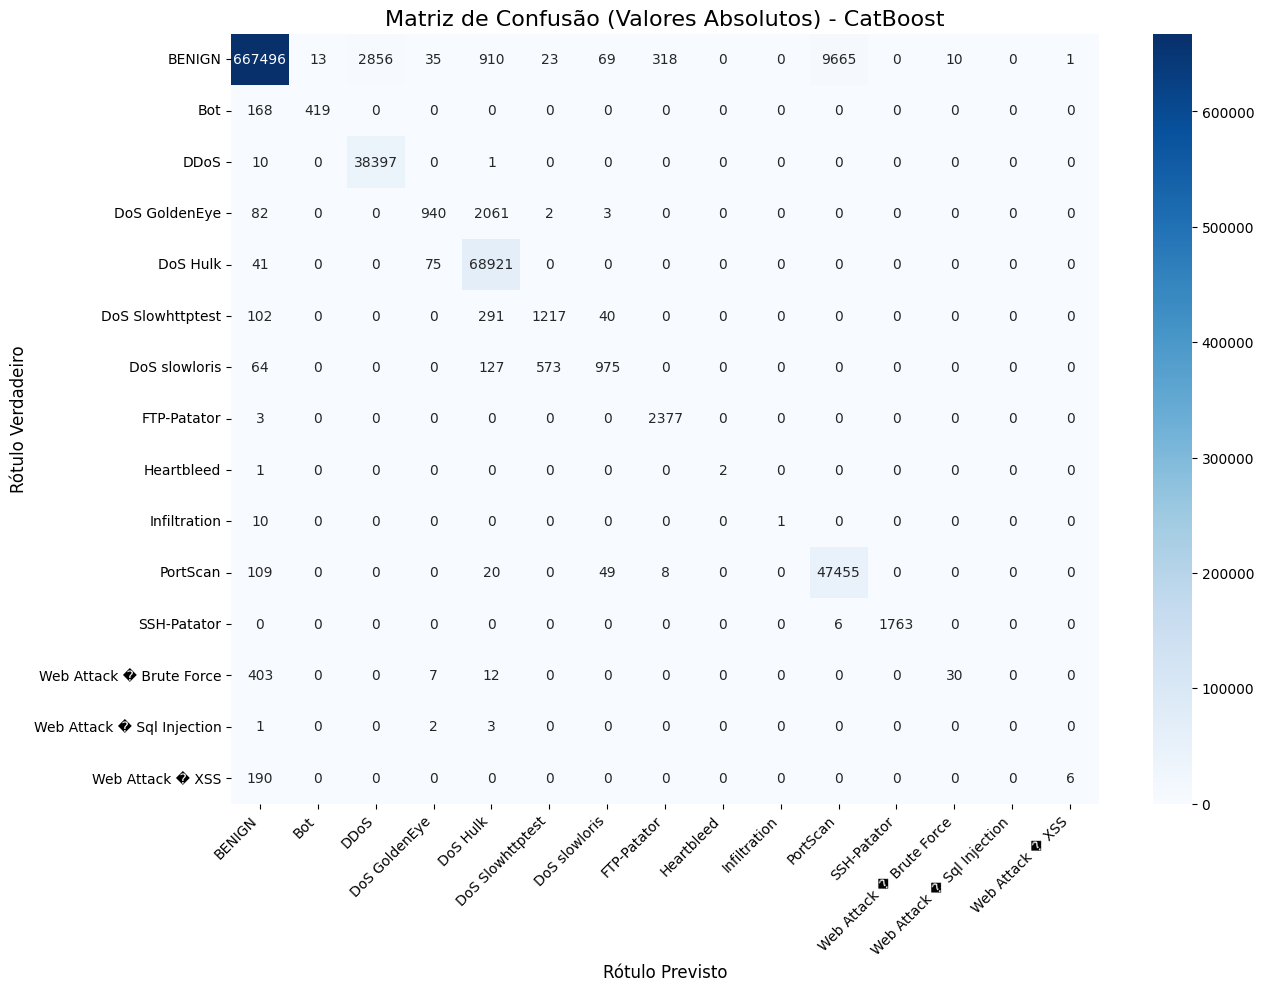

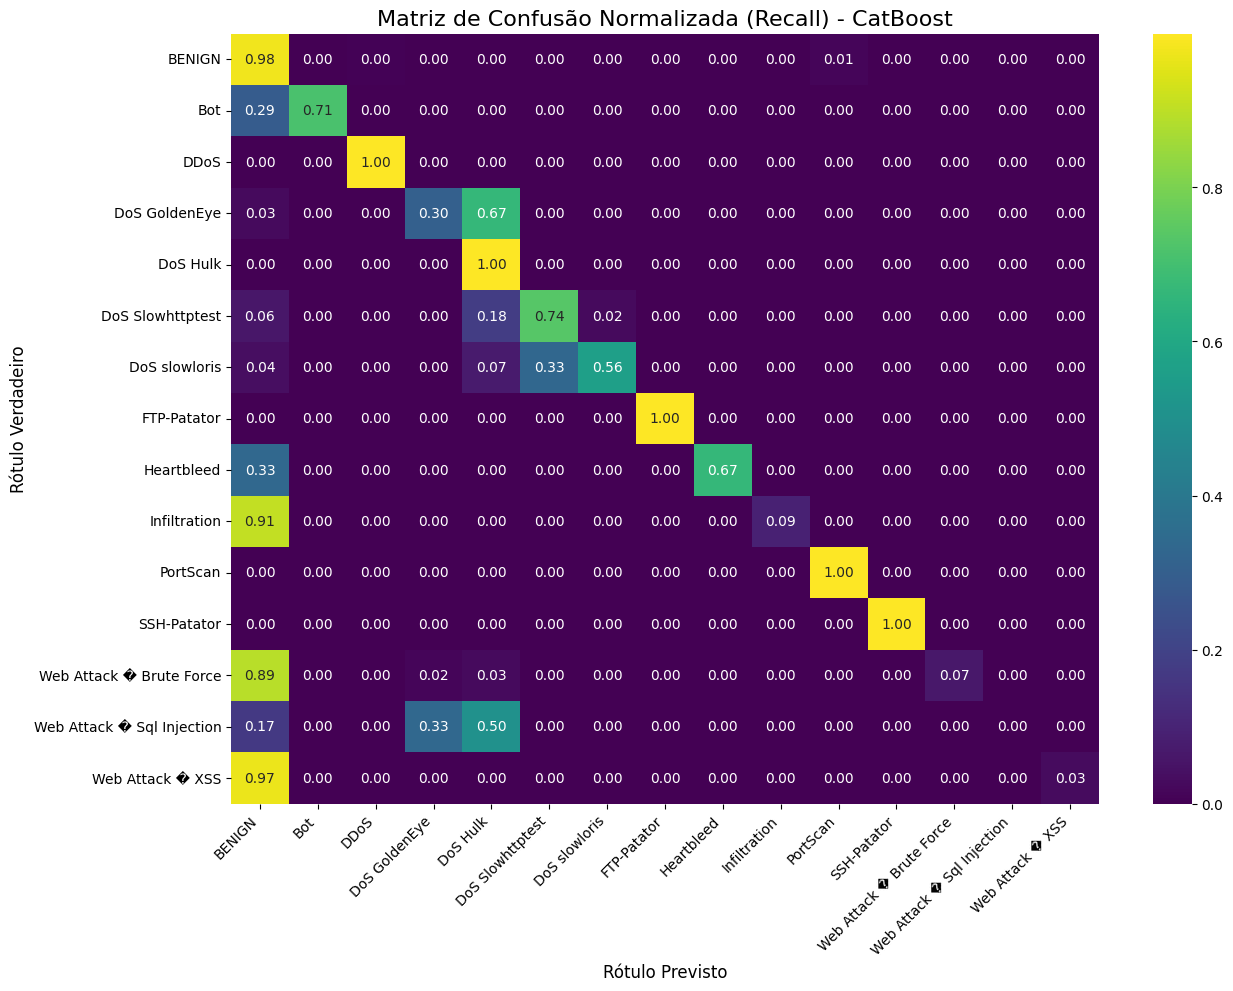

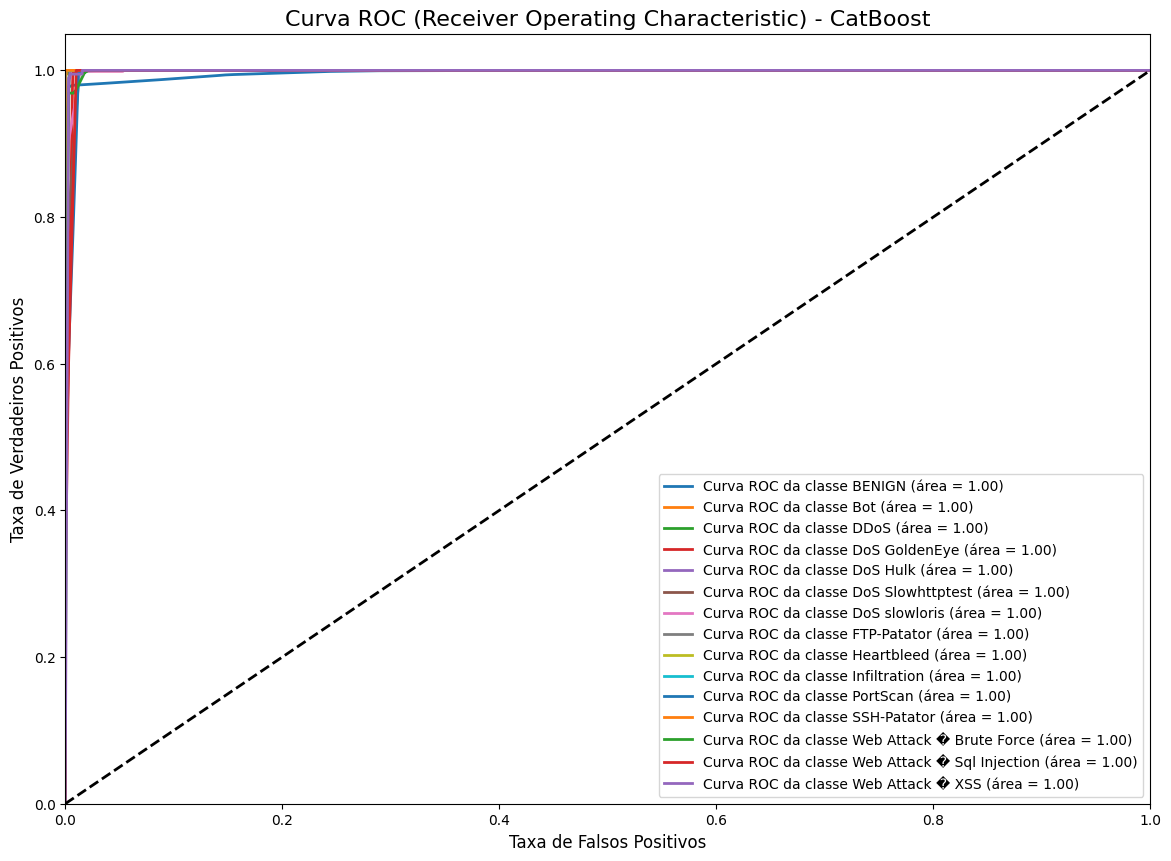

In [6]:
# O modelo já foi treinado. Agora, usamos o conjunto de teste para fazer previsões.
y_pred = cat_model.predict(X_teste)
y_pred_proba = cat_model.predict_proba(X_teste)

# --- Relatório de Classificação ---
print("--- Relatório de Classificação (CatBoost) ---")
print(classification_report(y_teste, y_pred, target_names=label_encoder.classes_.astype(str), zero_division=0))

# --- F1-Score Ponderado ---
f1 = f1_score(y_teste, y_pred, average='weighted')
print(f"\nF1-Score (Ponderado): {f1:.4f}")

# --- Matriz de Confusão (Absoluta) ---
cm_abs = confusion_matrix(y_teste, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm_abs, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_.astype(str), 
            yticklabels=label_encoder.classes_.astype(str))
plt.title('Matriz de Confusão (Valores Absolutos) - CatBoost', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# --- Matriz de Confusão (Normalizada/Recall) ---
cm_norm = cm_abs.astype('float') / cm_abs.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(14, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='viridis', 
            xticklabels=label_encoder.classes_.astype(str), 
            yticklabels=label_encoder.classes_.astype(str))
plt.title('Matriz de Confusão Normalizada (Recall) - CatBoost', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# --- Curva ROC (Um-contra-o-Resto) ---
from sklearn.preprocessing import label_binarize
y_teste_bin = label_binarize(y_teste, classes=np.arange(len(label_encoder.classes_)))
n_classes = y_teste_bin.shape[1]

fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_teste_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(14, 10))
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Curva ROC da classe {class_name} (área = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
plt.title('Curva ROC (Receiver Operating Characteristic) - CatBoost', fontsize=16)
plt.legend(loc="lower right")
plt.show()

### 6. Salvando o Modelo CatBoost

 O modelo CatBoost demonstrou uma performance excelente, especialmente no recall de classes raras, graças à sua estratégia de balanceamento automático.

 Ele se junta ao Random Forest e ao XGBoost como um dos principais candidatos para o nosso ensemble final, adicionando uma valiosa diversidade de "opinião" ao comitê.

 Vamos salvar o modelo treinado para uso futuro.

In [7]:
import os
import joblib

# --- Define o diretório de salvamento ---
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

# Garante que o diretório existe
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Diretório criado: {model_dir}")

# --- Salva o modelo treinado ---
model_path = os.path.join(model_dir, 'catboost_model.joblib')
joblib.dump(cat_model, model_path)
print(f"Modelo CatBoost salvo em: {model_path}")

# --- Verificação Final ---
print("\n--- Verificando arquivos salvos no diretório 'models' ---")
try:
    print(sorted(os.listdir(model_dir)))
except Exception as e:
    print(f"Não foi possível listar os arquivos: {e}")

Modelo CatBoost salvo em: /home/henrique/PycharmProjects/ndr-tcc/models/catboost_model.joblib

--- Verificando arquivos salvos no diretório 'models' ---
['catboost_model.joblib', 'ensemble_model.joblib', 'features_realistas.joblib', 'isolation_forest_model.joblib', 'label_encoder.joblib', 'mlp_model.joblib', 'random_forest_model.joblib', 'top_15_features.joblib', 'xgboost_model.joblib']
